In [1]:
from serl_sprl.envs.quadrotor.quadrotor_coupled_dynamics import Quad2dCoupledEnvConfig, Quad2dProjConfig
from serl_sprl.benchmarking.environments import EnvCreatorFactory
from serl_sprl.visualization_densities.helpers import *
from typing import Union
import gymnasium as gym
import numpy as np
import torch as th
from torch.distributions.multivariate_normal import MultivariateNormal
import matplotlib.pyplot as plt
import torch.nn as nn


/home/hannah/Documents/Code/serl_sprl/.venv/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [2]:
def rescale_actions(actions: Union[th.Tensor, np.ndarray], action_low: np.ndarray, action_high: np.ndarray) -> Union[th.Tensor, np.ndarray]:
    """Scale actions from [-1, 1] to [action_low, action_high].

    Args:
        actions (Union[th.Tensor, np.ndarray]): Actions in the range [-1, 1].
        action_low (np.ndarray): Lower bounds of the action space.
        action_high (np.ndarray): Upper bounds of the action space.

    Returns:
        Union[th.Tensor, np.ndarray]: Scaled actions in the range [action_low, action_high].
    """
    if isinstance(actions, th.Tensor):
        action_low_tensor = th.tensor(action_low, dtype=actions.dtype, device=actions.device)
        action_high_tensor = th.tensor(action_high, dtype=actions.dtype, device=actions.device)
        scaled_actions = action_low_tensor + (actions + 1.0) * 0.5 * (action_high_tensor - action_low_tensor)
    else:
        scaled_actions = action_low + (actions + 1.0) * 0.5 * (action_high - action_low)
    return scaled_actions

def scale_actions(actions: Union[th.Tensor, np.ndarray], action_low: np.ndarray, action_high: np.ndarray) -> Union[th.Tensor, np.ndarray]:
    """Rescale actions from [action_low, action_high] to [-1, 1].

    Args:
        actions (Union[th.Tensor, np.ndarray]): Actions in the range [action_low, action_high].
        action_low (np.ndarray): Lower bounds of the action space.
        action_high (np.ndarray): Upper bounds of the action space.

    Returns:
        Union[th.Tensor, np.ndarray]: Rescaled actions in the range [-1, 1].
    """
    if isinstance(actions, th.Tensor):
        action_low_tensor = th.tensor(action_low, dtype=actions.dtype, device=actions.device)
        action_high_tensor = th.tensor(action_high, dtype=actions.dtype, device=actions.device)
        rescaled_actions = 2.0 * (actions - action_low_tensor) / (action_high_tensor - action_low_tensor) - 1.0
    else:
        rescaled_actions = 2.0 * (actions - action_low) / (action_high - action_low) - 1.0
    return rescaled_actions

def apply_squashing_correction(log_probs, actions, epsilon=1e-6):
    """
    Apply the change-of-variables correction for tanh squashing.
    
    When actions are squashed through tanh, we need to correct the log probabilities
    to account for the Jacobian of the transformation.
    
    Args:
        log_probs: Log probabilities from the Gaussian distribution
        actions: Squashed actions (after tanh)
        epsilon: Small value to avoid NaN in log computation
        
    Returns:
        Corrected log probabilities accounting for the tanh transformation
    """
    # Compute log |det(Jacobian)| = sum_i log(1 - tanh(x_i)^2)
    log_prob_correction = th.log(1.0 - actions**2 + epsilon).sum(dim=-1)
    return log_probs - log_prob_correction

In [3]:
class PolicyMeanNetwork(nn.Module):
    """Simple policy mean network with optional tanh squashing."""
    
    def __init__(self, action_dim: int = 2, squash_mean: bool = True):
        """
        Args:
            action_dim: Dimension of the action space
            squash_mean: Whether to apply tanh squashing to the output
        """
        super().__init__()
        self.action_dim = action_dim
        self.squash_mean = squash_mean
        
        # Simple linear layer (just learns the bias/mean)
        self.linear = nn.Linear(1, action_dim, bias=True)
        
        # Initialize weights to zero so only bias matters
        with th.no_grad():
            self.linear.weight.zero_()
    
    def forward(self, x):
        """Forward pass through the network.
        
        Args:
            x: Dummy input tensor (not used, just for compatibility)
            
        Returns:
            Mean action, optionally squashed through tanh
        """
        output = self.linear(x)
        if self.squash_mean:
            output = th.tanh(output)
        return output
    
    def initialize_bias(self, initial_value: th.Tensor):
        """Initialize the bias to a specific value.
        
        Args:
            initial_value: Initial mean value (will be passed through arctanh if squash_mean is True)
        """
        with th.no_grad():
            if self.squash_mean:
                # For tanh squashing, initialize with arctanh of the desired output
                clamped_value = th.clamp(initial_value, -0.99, 0.99)
                self.linear.bias.copy_(th.atanh(clamped_value))
            else:
                # Without squashing, directly set the bias
                self.linear.bias.copy_(initial_value)

We start by computing the safe action set for a given state based on maximizing the volume of a template set.

In [4]:
# --- Seeding ---
np.random.seed(42)
th.manual_seed(42)

env_config = Quad2dCoupledEnvConfig(randomize_env=True)
proj_config = Quad2dProjConfig()
if not (env_config.id in gym.envs.registry.keys()):
    from gymnasium.envs.registration import register

    register(id=env_config.id, entry_point="serl_sprl.envs.quadrotor:Quad2dCoupledEnv")

proj_config = proj_config.model_dump()
env_factory = EnvCreatorFactory(approach="sprl", improvement_strategy="none", env_id=env_config.id)
env_creator = env_factory.get_env_creator(wrapper_kwargs=proj_config)
env = env_creator.create_env(env_config)
# Now we can compute the safe action set for a given state
safe_action_set = compute_safe_set(NUM_GENERATORS, proj_config, env, CURRENT_STATE)


/home/hannah/Documents/Code/serl_sprl/.venv/lib/python3.10/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/hannah/Documents/Code/serl_sprl/.venv/lib/python3.10/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
/home/hannah/Documents/Code/serl_sprl/.venv/lib/python3.10/site-packages/cvxpy/atoms/affine/reshape.py:68: FutureWarning: 
    You didn't specify the order of the reshape expression. The default order
    used in CVXPY is Fortran ('F') order. This default will change to match NumPy's
    default order ('C') in a future version of CVXPY.
    To suppress this warning, please specify the order explicitly.
    
  warnings.warn(reshape_order_warning, FutureWarning)


In [5]:
# --- Parameters ---
u_range = env.envs[0].get_wrapper_attr("u_range")
initial_mean_unscaled = th.tensor([7.4, 8.25], requires_grad=True)
initial_mean_scaled = scale_actions(initial_mean_unscaled, u_range[0, :], u_range[1, :])
mu = initial_mean_scaled.clone().detach().requires_grad_(True)
log_variance = th.tensor([0.0, 0.0], requires_grad=True)  # Use log-variance for numerical stability

# Create CVXPY layer for projection
projection_layer = create_layer_safe_action_set(safe_action_set.c, safe_action_set.G)

In [6]:
# There are many potential optimal actions here, so we use the one that the baseline policy without projection converges to
opt_safe_action = [7.7076, 7.9415]

We will now run a few policy update steps for the given state

In [13]:
# Multi-step optimization with parallel unprojected and projected policies
n_steps = 50
n_samples = 2000
lr = 0.3

# Enhancements
psl = False
pen_c = False
penalty_factor = 0.5
squash_mean = True  # Whether to use tanh squashing
squash_samples = True  # Whether to use tanh squashing for samples

# Initialize policy mean networks
mu_unproj_net = PolicyMeanNetwork(action_dim=2, squash_mean=squash_mean)
mu_proj_net = PolicyMeanNetwork(action_dim=2, squash_mean=squash_mean)

# Initialize with the initial mean value
mu_unproj_net.initialize_bias(mu)
mu_proj_net.initialize_bias(mu)

log_var_unproj = th.tensor([0.0, 0.0], requires_grad=True)
log_var_proj = th.tensor([0.0, 0.0], requires_grad=True)

# Create optimizers
optimizer_unproj = th.optim.SGD([{'params': mu_unproj_net.parameters()}, {'params': log_var_unproj}], lr=lr)
optimizer_proj = th.optim.SGD([{'params': mu_proj_net.parameters()}, {'params': log_var_proj}], lr=lr)

# for plotting
dummy_input = th.ones((1, 1))  # Dummy input for the policy networks
mu_start = mu_unproj_net(dummy_input).clone().detach().numpy()

# Storage for tracking evolution
mu_unproj_history = []
mu_proj_history = []
loss_unproj_history = []
loss_proj_history = []

print("Starting multi-step optimization...")
print(f"Learning rate: {lr}")
print(f"Samples per iteration: {n_samples}")
print(f"Squash mean: {squash_mean}")
print(f"Squash samples: {squash_samples}")
print("-" * 50)

for step in range(n_steps):
    print(f"Step {step + 1}/{n_steps}")
    
    # ============ UNPROJECTED POLICY ============
    optimizer_unproj.zero_grad()

    # Get mean from network (already in [-1, 1] if squashed)
    mu_unproj = mu_unproj_net(dummy_input).squeeze(0)
    mu_unproj_unscaled = rescale_actions(mu_unproj, u_range[0, :], u_range[1, :])
    
    # Create distribution and sample
    cov_unproj = th.diag_embed(th.exp(log_var_unproj))
    dist_unproj = MultivariateNormal(mu_unproj, cov_unproj)
    samples_unproj = dist_unproj.sample((n_samples,))
    log_prob_unproj = dist_unproj.log_prob(samples_unproj)

    if squash_samples:
        samples_unproj = th.tanh(samples_unproj)
        log_prob_unproj = apply_squashing_correction(log_prob_unproj, samples_unproj)

    # Rescale samples to original action space
    samples_unproj_unscaled = rescale_actions(samples_unproj, u_range[0, :], u_range[1, :])
    
    # Project samples (for consistent reward evaluation)
    projected_samples_unproj_unscaled = projection_layer(
        samples_unproj_unscaled, 
        th.tensor(safe_action_set.c.flatten(), dtype=th.float32), 
        th.tensor(safe_action_set.G, dtype=th.float32)
        )[0]
    
    # scale back projected samples to [-1, 1]
    projected_samples_unproj = scale_actions(projected_samples_unproj_unscaled, u_range[0, :], u_range[1, :])

    # Compute next states
    next_states_unproj = dynamics_quadrotor(state=CURRENT_STATE.reshape(1, -1), actions=projected_samples_unproj_unscaled, env=env)
    
    # Compute unprojected loss (reward * unprojected log prob)
    unproj_values = reward_quadrotor(state=next_states_unproj, action=projected_samples_unproj_unscaled)
    if pen_c:
        unproj_values -= penalty_factor * th.norm(samples_unproj - projected_samples_unproj, dim=1)**2
    unproj_rewards = unproj_values * log_prob_unproj
    loss_unproj = -th.mean(unproj_rewards)  # Negate because optimizer minimizes
    if psl:
        proj_mean_unscaled = projection_layer(
            mu_unproj_unscaled.unsqueeze(0), 
            th.tensor(safe_action_set.c.flatten(), dtype=th.float32), 
            th.tensor(safe_action_set.G, dtype=th.float32)
            )[0].squeeze(0)
        proj_mean = scale_actions(proj_mean_unscaled, u_range[0, :], u_range[1, :])
        loss_unproj += penalty_factor * th.norm(proj_mean - mu_unproj)**2  # Add penalty (was subtracted)
    
    # Backward pass and update
    loss_unproj.backward()
    optimizer_unproj.step()
    
    # ============ PROJECTED POLICY ============
    optimizer_proj.zero_grad()

    # Get mean from network (already in [-1, 1] if squashed)
    mu_proj = mu_proj_net(dummy_input).squeeze(0)
    
    # Create distribution and sample
    cov_proj = th.diag_embed(th.exp(log_var_proj))
    dist_proj = MultivariateNormal(mu_proj, cov_proj)
    samples_proj_gaussian = dist_proj.sample((n_samples,))
    log_prob_proj_gaussian = dist_proj.log_prob(samples_proj_gaussian)

    # rescale mean to original action space
    mu_proj_unscaled = rescale_actions(mu_proj, u_range[0, :], u_range[1, :])

    # Rescale samples to original action space
    samples_proj_unscaled = rescale_actions(samples_proj_gaussian, u_range[0, :], u_range[1, :])
    
    # Project samples
    projected_samples_proj_unscaled = projection_layer(
        samples_proj_unscaled, 
        th.tensor(safe_action_set.c.flatten(), dtype=th.float32), 
        th.tensor(safe_action_set.G, dtype=th.float32)
        )[0]
    
    # scale back projected samples to [-1, 1]
    projected_samples_proj = scale_actions(projected_samples_proj_unscaled, u_range[0, :], u_range[1, :])
    
    # Compute next states
    next_states_proj = dynamics_quadrotor(state=CURRENT_STATE.reshape(1, -1), actions=projected_samples_proj_unscaled, env=env)

    # Compute hybrid log probabilities
    projection_distance = th.norm(projected_samples_proj - samples_proj_gaussian, dim=1)
    projected_mask = projection_distance >= 1e-5
    normal_vectors = (samples_proj_gaussian - projected_samples_proj) / projection_distance.unsqueeze(1)
    normal_vectors = th.where(projection_distance.unsqueeze(1) < 1e-6, th.ones_like(normal_vectors), normal_vectors)
    boundary_densities = compute_gaussian_boundary_mass_torch(
        mu_proj,
        th.exp(log_var_proj),
        boundary_points=projected_samples_proj,
        normals=normal_vectors,
        t_max=10.0
        )
    hybrid_log_prob_gaussian = th.where(projected_mask, th.log(boundary_densities), log_prob_proj_gaussian)

    # NOW apply squashing if needed
    if squash_samples:
        samples_proj = th.tanh(samples_proj_gaussian)
        projected_samples_proj = th.tanh(projected_samples_proj)
        
        # Apply correction to hybrid log prob
        # For non-projected samples: standard correction
        # For projected samples: also apply correction
        correction_original = th.log(1.0 - samples_proj**2 + 1e-6).sum(dim=-1)
        correction_projected = th.log(1.0 - projected_samples_proj**2 + 1e-6).sum(dim=-1)
        
        hybrid_log_prob = th.where(
            projected_mask,
            hybrid_log_prob_gaussian - correction_projected,
            hybrid_log_prob_gaussian - correction_original
        )
    else:
        samples_proj = samples_proj_gaussian
        hybrid_log_prob = hybrid_log_prob_gaussian
    
    # Compute projected loss (reward * hybrid log prob)
    values = reward_quadrotor(state=next_states_proj, action=projected_samples_proj_unscaled)
    proj_rewards = values * hybrid_log_prob
    loss_proj = -th.mean(proj_rewards)  # Negate because optimizer minimizes

    if pen_c:
        penalties = penalty_factor * th.norm(samples_proj - projected_samples_proj.detach(), dim=1)**2
        loss_proj += th.mean(penalties * apply_squashing_correction(log_prob_proj_gaussian, samples_proj_gaussian)) 

    if psl:
        proj_mean_proj_unscaled = projection_layer(
            mu_proj_unscaled.unsqueeze(0), 
            th.tensor(safe_action_set.c.flatten(), dtype=th.float32), 
            th.tensor(safe_action_set.G, dtype=th.float32)
            )[0].squeeze(0)
        proj_mean_proj = scale_actions(proj_mean_proj_unscaled, u_range[0, :], u_range[1, :])
        loss_proj += penalty_factor * th.norm(proj_mean_proj - mu_proj)**2  
    
    # Backward pass and update
    loss_proj.backward()
    optimizer_proj.step()
    
    # ============ STORE RESULTS ============
    mu_unproj_history.append(mu_unproj_unscaled.clone().detach())
    mu_proj_history.append(mu_proj_unscaled.clone().detach())
    loss_unproj_history.append(-loss_unproj.item())  # Store as positive reward for plotting
    loss_proj_history.append(-loss_proj.item())  # Store as positive reward for plotting
    
    # Print progress
    print(f"  Unprojected: μ = [{mu_unproj_unscaled[0]:.3f}, {mu_unproj_unscaled[1]:.3f}], loss = {loss_unproj.item():.4f}")
    print(f"  Projected:   μ = [{mu_proj_unscaled[0]:.3f}, {mu_proj_unscaled[1]:.3f}], loss = {loss_proj.item():.4f}")
    print()

print("Optimization complete!")
print(f"Final unprojected mean: [{mu_unproj_unscaled[0]:.3f}, {mu_unproj_unscaled[1]:.3f}]")
print(f"Final unprojected covariance: [{th.exp(log_var_unproj)[0]:.3f}, {th.exp(log_var_unproj)[1]:.3f}]")
print(f"Final projected mean:   [{mu_proj_unscaled[0]:.3f}, {mu_proj_unscaled[1]:.3f}]")
print(f"Final projected covariance:   [{th.exp(log_var_proj)[0]:.3f}, {th.exp(log_var_proj)[1]:.3f}]")


Starting multi-step optimization...
Learning rate: 0.3
Samples per iteration: 2000
Squash mean: True
Squash samples: True
--------------------------------------------------
Step 1/50


/tmp/ipykernel_87056/3214495498.py:71: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  th.tensor(safe_action_set.c.flatten(), dtype=th.float32),
/tmp/ipykernel_87056/3214495498.py:72: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  th.tensor(safe_action_set.G, dtype=th.float32)
/tmp/ipykernel_87056/3214495498.py:121: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  th.tensor(safe_action_set.c.flatten(), dtype=th.float32),
/tmp/ipykernel_87056/3214495498.py:122: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.d

integral.max(): tensor(0.3226, grad_fn=<MaxBackward1>)
integral.min(): tensor(0.0593, grad_fn=<MinBackward1>)
  Unprojected: μ = [7.400, 8.250], loss = -0.5467
  Projected:   μ = [7.400, 8.250], loss = -0.8252

Step 2/50
integral.max(): tensor(0.3275, grad_fn=<MaxBackward1>)
integral.min(): tensor(0.0576, grad_fn=<MinBackward1>)
  Unprojected: μ = [7.409, 8.247], loss = -0.5392
  Projected:   μ = [7.379, 8.246], loss = -0.8235

Step 3/50
integral.max(): tensor(0.3275, grad_fn=<MaxBackward1>)
integral.min(): tensor(0.0576, grad_fn=<MinBackward1>)
  Unprojected: μ = [7.409, 8.247], loss = -0.5392
  Projected:   μ = [7.379, 8.246], loss = -0.8235

Step 3/50
integral.max(): tensor(0.3132, grad_fn=<MaxBackward1>)
integral.min(): tensor(0.0564, grad_fn=<MinBackward1>)
  Unprojected: μ = [7.409, 8.240], loss = -0.5441
  Projected:   μ = [7.363, 8.242], loss = -0.8333

Step 4/50
integral.max(): tensor(0.3132, grad_fn=<MaxBackward1>)
integral.min(): tensor(0.0564, grad_fn=<MinBackward1>)
  Unpr

Plotting...

/tmp/ipykernel_87056/3932858608.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  th.tensor(safe_action_set.c.flatten(), dtype=th.float32),
/tmp/ipykernel_87056/3932858608.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  th.tensor(safe_action_set.G, dtype=th.float32)


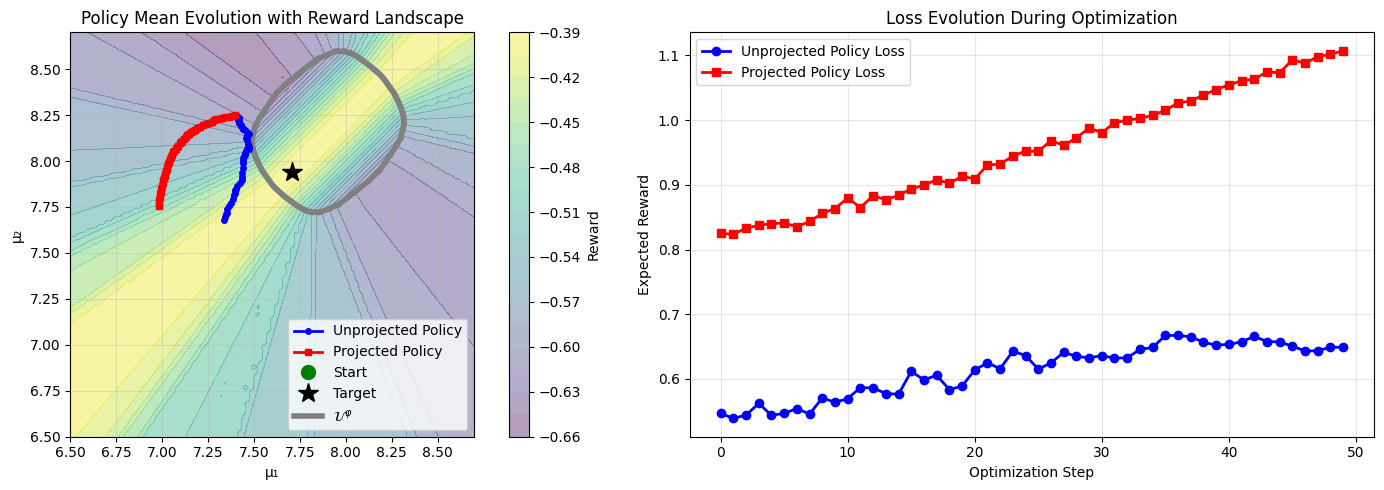

In [15]:
# Plot the evolution of both policies
fig, axes = plt.subplots(figsize=(15, 5), ncols=2)

# Convert histories to numpy for plotting
mu_unproj_np = th.stack(mu_unproj_history).detach().cpu().numpy()
mu_proj_np = th.stack(mu_proj_history).detach().cpu().numpy()

# Plot 1: Trajectory in 2D space with reward landscape
ax = axes[0]

# Create a grid for the reward landscape
u1_grid = np.linspace(6.5, 8.7, 100)
u2_grid = np.linspace(6.5, 8.7, 100)
U1, U2 = np.meshgrid(u1_grid, u2_grid)

# Compute rewards on the grid
grid_actions = th.tensor(np.stack([U1.ravel(), U2.ravel()], axis=1), dtype=th.float32)
# Project grid actions to safe set for fair evaluation
projected_grid_actions = projection_layer(
    grid_actions,
    th.tensor(safe_action_set.c.flatten(), dtype=th.float32),
    th.tensor(safe_action_set.G, dtype=th.float32)
)[0]
# Compute next states for grid
next_states_grid = dynamics_quadrotor(state=CURRENT_STATE.reshape(1, -1), actions=projected_grid_actions, env=env)
# Compute rewards
rewards_grid = reward_quadrotor(state=next_states_grid, action=projected_grid_actions)
rewards_grid = rewards_grid.detach().cpu().numpy().reshape(U1.shape)

# Plot reward landscape as colormap
contour = ax.contourf(U1, U2, rewards_grid, levels=20, cmap='viridis', alpha=0.4)
cbar = plt.colorbar(contour, ax=ax, label='Reward')

# Plot trajectories on top
ax.plot(mu_unproj_np[:, 0], mu_unproj_np[:, 1], 'b-o', label='Unprojected Policy', linewidth=2, markersize=4, zorder=3)
ax.plot(mu_proj_np[:, 0], mu_proj_np[:, 1], 'r-s', label='Projected Policy', linewidth=2, markersize=4, zorder=3)

# Mark start and end points
ax.plot(mu_start[0, 0], mu_start[0, 1], 'go', markersize=10, label='Start', zorder=4)
ax.plot(opt_safe_action[0], opt_safe_action[1], 'k*', markersize=15, label='Target', zorder=4)

# Add safe action set boundary
plot_shape(ax, safe_action_set.vertices, label=r'$\mathcal{U}^\varphi$', color='grey')
ax.set_xlabel('μ₁')
ax.set_ylabel('μ₂')
ax.set_title('Policy Mean Evolution with Reward Landscape')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([6.5, 8.7])
ax.set_ylim([6.5, 8.7])
ax.set_aspect('equal')

# Plot 2: Loss evolution over time
ax = axes[1]
ax.plot(range(len(loss_unproj_history)), loss_unproj_history, 'b-o', label='Unprojected Policy Loss', linewidth=2)
ax.plot(range(len(loss_proj_history)), loss_proj_history, 'r-s', label='Projected Policy Loss', linewidth=2)
ax.set_xlabel('Optimization Step')
ax.set_ylabel('Expected Reward')
ax.set_title('Loss Evolution During Optimization')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
mu_start[0, 0]

np.float32(-0.35841805)

Let's do a PPO-style update next. 

In [ ]:
# Add this cell after cell #VSC-3199f9e4

# PPO-style optimization with parallel unprojected and projected policies
n_steps = 20
n_samples = 2000
lr = 0.001  # Lower learning rate for PPO-style updates
minibatch_size = 500
n_minibatches = n_samples // minibatch_size
n_epochs_per_step = 5  # Number of times to iterate over the same samples
clip_epsilon = 0.2  # PPO clipping parameter

# Enhancements
psl = True
pen_c = True
penalty_factor = 0.5

# Initialize parameters for both policies
mu_unproj = th.tensor(mu.clone(), requires_grad=True)
log_var_unproj = th.tensor([0.0, 0.0], requires_grad=True)
mu_proj = th.tensor(mu.clone(), requires_grad=True)
log_var_proj = th.tensor([0.0, 0.0], requires_grad=True)

# Optimizers for both policies
optimizer_unproj = th.optim.SGD([mu_unproj, log_var_unproj], lr=lr)
optimizer_proj = th.optim.SGD([mu_proj, log_var_proj], lr=lr)

# For plotting
mu_start = mu_unproj.clone().detach()

# Storage for tracking evolution
mu_unproj_history = []
mu_proj_history = []
loss_unproj_history = []
loss_proj_history = []

print("Starting PPO-style multi-step optimization...")
print(f"Learning rate: {lr}")
print(f"Samples per iteration: {n_samples}")
print(f"Minibatch size: {minibatch_size}")
print(f"Epochs per step: {n_epochs_per_step}")
print(f"Clip epsilon: {clip_epsilon}")
print("-" * 50)

for step in range(n_steps):
    print(f"Step {step + 1}/{n_steps}")
    
    # ============ COLLECT SAMPLES AND COMPUTE OLD LOG PROBS ============
    
    # Unprojected policy
    with th.no_grad():
        cov_unproj = th.diag_embed(th.exp(log_var_unproj))
        dist_unproj_old = MultivariateNormal(mu_unproj, cov_unproj)
        samples_unproj = dist_unproj_old.sample((n_samples,))
        old_log_probs_unproj = dist_unproj_old.log_prob(samples_unproj)
        
        # Project samples
        projected_samples_unproj = projection_layer(
            samples_unproj,
            th.tensor(safe_action_set.c.flatten(), dtype=th.float32),
            th.tensor(safe_action_set.G, dtype=th.float32)
        )[0]
        
        # Compute next states and advantages
        next_states_unproj = dynamics_quadrotor(
            state=CURRENT_STATE.reshape(1, -1),
            actions=projected_samples_unproj,
            env=env
        )
        rewards_unproj = reward_quadrotor(state=next_states_unproj, action=projected_samples_unproj)
        advantages_unproj = rewards_unproj

    # Projected policy
    with th.no_grad():
        cov_proj = th.diag_embed(th.exp(log_var_proj))
        dist_proj_old = MultivariateNormal(mu_proj, cov_proj)
        samples_proj = dist_proj_old.sample((n_samples,))
        
        # Project samples
        projected_samples_proj = projection_layer(
            samples_proj,
            th.tensor(safe_action_set.c.flatten(), dtype=th.float32),
            th.tensor(safe_action_set.G, dtype=th.float32)
        )[0]
        
        # Compute projection info for hybrid log prob
        projection_distance = th.norm(projected_samples_proj - samples_proj, dim=1)
        projected_mask = projection_distance >= 1e-5
        normal_vectors = (samples_proj - projected_samples_proj) / projection_distance.unsqueeze(1)
        normal_vectors = th.where(projection_distance.unsqueeze(1) < 1e-6, th.ones_like(normal_vectors), normal_vectors)
        
        # Compute old hybrid log probs
        boundary_densities_old = compute_gaussian_boundary_mass_torch(
            mu_proj,
            th.exp(log_var_proj),
            boundary_points=projected_samples_proj,
            normals=normal_vectors,
            t_max=10.0
        )
        old_log_probs_proj = th.where(
            projected_mask,
            th.log(boundary_densities_old + 1e-8),
            dist_proj_old.log_prob(samples_proj)
        )

        old_log_probs_proj_orig = dist_proj_old.log_prob(samples_proj)
        
        # Compute next states and advantages
        next_states_proj = dynamics_quadrotor(
            state=CURRENT_STATE.reshape(1, -1),
            actions=projected_samples_proj,
            env=env
        )
        rewards_proj = reward_quadrotor(state=next_states_proj, action=projected_samples_proj)
        advantages_proj = rewards_proj
    
    # ============ PPO UPDATE EPOCHS ============
    
    step_losses_unproj = []
    step_losses_proj = []
    
    for epoch in range(n_epochs_per_step):
        # Shuffle indices for minibatching
        indices = th.randperm(n_samples)
        
        for i in range(n_minibatches):
            # Get minibatch indices
            mb_indices = indices[i * minibatch_size:(i + 1) * minibatch_size]
            
            # ============ UNPROJECTED POLICY UPDATE ============
            if pen_c:
                penalties_unproj = penalty_factor * th.norm(samples_unproj - projected_samples_unproj, dim=1)**2
                advantages_unproj -= penalties_unproj
            optimizer_unproj.zero_grad()
            
            # Recompute log probs with current policy
            cov_unproj = th.diag_embed(th.exp(log_var_unproj))
            dist_unproj = MultivariateNormal(mu_unproj, cov_unproj)
            new_log_probs_unproj = dist_unproj.log_prob(samples_unproj[mb_indices])
            
            # Compute ratio and clipped objective
            ratio_unproj = th.exp(new_log_probs_unproj - old_log_probs_unproj[mb_indices])
            surr1_unproj = ratio_unproj * advantages_unproj[mb_indices]
            surr2_unproj = th.clamp(ratio_unproj, 1.0 - clip_epsilon, 1.0 + clip_epsilon) * advantages_unproj[mb_indices]
            loss_unproj = -th.mean(th.min(surr1_unproj, surr2_unproj))
            
            # Add PSL penalty
            if psl:
                proj_mean = projection_layer(
                    mu_unproj.unsqueeze(0),
                    th.tensor(safe_action_set.c.flatten(), dtype=th.float32),
                    th.tensor(safe_action_set.G, dtype=th.float32)
                )[0].squeeze(0)
                loss_unproj += penalty_factor * th.norm(proj_mean - mu_unproj)**2
            
            loss_unproj.backward()
            optimizer_unproj.step()
            step_losses_unproj.append(loss_unproj.item())
            
            # ============ PROJECTED POLICY UPDATE ============
            optimizer_proj.zero_grad()
            
            # Recompute hybrid log probs with current policy
            cov_proj = th.diag_embed(th.exp(log_var_proj))
            dist_proj = MultivariateNormal(mu_proj, cov_proj)
            
            # Recompute boundary densities with current parameters
            mb_projection_distance = projection_distance[mb_indices]
            mb_projected_mask = projected_mask[mb_indices]
            mb_normal_vectors = normal_vectors[mb_indices]
            mb_projected_samples = projected_samples_proj[mb_indices]
            mb_samples = samples_proj[mb_indices]
            
            boundary_densities = compute_gaussian_boundary_mass_torch(
                mu_proj,
                th.exp(log_var_proj),
                boundary_points=mb_projected_samples,
                normals=mb_normal_vectors,
                t_max=10.0
            )
            
            new_log_probs_proj = th.where(
                mb_projected_mask,
                th.log(boundary_densities + 1e-8),
                dist_proj.log_prob(mb_samples)
            )
            
            # Compute ratio and clipped objective
            ratio_proj = th.exp(new_log_probs_proj - old_log_probs_proj[mb_indices])
            surr1_proj = ratio_proj * advantages_proj[mb_indices]
            surr2_proj = th.clamp(ratio_proj, 1.0 - clip_epsilon, 1.0 + clip_epsilon) * advantages_proj[mb_indices]
            loss_proj = -th.mean(th.min(surr1_proj, surr2_proj))
            
            # Add PSL penalty
            if psl:
                proj_mean_proj = projection_layer(
                    mu_proj.unsqueeze(0),
                    th.tensor(safe_action_set.c.flatten(), dtype=th.float32),
                    th.tensor(safe_action_set.G, dtype=th.float32)
                )[0].squeeze(0)
                loss_proj += penalty_factor * th.norm(proj_mean_proj - mu_proj)**2
            
            if pen_c:
                penalties = penalty_factor * th.norm(mb_samples - mb_projected_samples.detach(), dim=1)**2
                ratio_proj_original = th.exp(dist_proj.log_prob(mb_samples) - old_log_probs_proj_orig[mb_indices])
                surr1_proj_original = ratio_proj_original * penalties
                surr2_proj_original = th.clamp(ratio_proj_original, 1.0 - clip_epsilon, 1.0 + clip_epsilon) * penalties
                loss_proj += th.mean(th.min(surr1_proj_original, surr2_proj_original))
                # Alternatively, simpler penalty term
                # loss_proj += th.mean(penalties * dist_proj.log_prob(mb_samples))
            
            loss_proj.backward()
            optimizer_proj.step()
            step_losses_proj.append(loss_proj.item())
    
    # ============ STORE RESULTS ============
    mu_unproj_history.append(mu_unproj.clone().detach())
    mu_proj_history.append(mu_proj.clone().detach())
    avg_loss_unproj = np.mean(step_losses_unproj)
    avg_loss_proj = np.mean(step_losses_proj)
    loss_unproj_history.append(-avg_loss_unproj)  # Negate because we minimized negative advantage
    loss_proj_history.append(-avg_loss_proj)
    
    # Print progress
    print(f"  Unprojected: μ = [{mu_unproj[0]:.3f}, {mu_unproj[1]:.3f}], avg_loss = {avg_loss_unproj:.4f}")
    print(f"  Projected:   μ = [{mu_proj[0]:.3f}, {mu_proj[1]:.3f}], avg_loss = {avg_loss_proj:.4f}")
    print()

print("PPO-style optimization complete!")
print(f"Final unprojected mean: [{mu_unproj[0]:.3f}, {mu_unproj[1]:.3f}]")
print(f"Final unprojected covariance: [{th.exp(log_var_unproj)[0]:.3f}, {th.exp(log_var_unproj)[1]:.3f}]")
print(f"Final projected mean:   [{mu_proj[0]:.3f}, {mu_proj[1]:.3f}]")
print(f"Final projected covariance:   [{th.exp(log_var_proj)[0]:.3f}, {th.exp(log_var_proj)[1]:.3f}]")

/tmp/ipykernel_46854/3565716121.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mu_unproj = th.tensor(mu.clone(), requires_grad=True)
/tmp/ipykernel_46854/3565716121.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mu_proj = th.tensor(mu.clone(), requires_grad=True)
/tmp/ipykernel_46854/3565716121.py:59: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  th.tensor(safe_action_set.c.flatten(), dtype=th.float32),
/tmp/ipykernel_46854/3565716121.py:60: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.de

Starting PPO-style multi-step optimization...
Learning rate: 0.001
Samples per iteration: 2000
Minibatch size: 500
Epochs per step: 5
Clip epsilon: 0.2
--------------------------------------------------
Step 1/20


/tmp/ipykernel_46854/3565716121.py:81: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  th.tensor(safe_action_set.c.flatten(), dtype=th.float32),
/tmp/ipykernel_46854/3565716121.py:82: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  th.tensor(safe_action_set.G, dtype=th.float32)


integral.max(): tensor(0.3102)
integral.min(): tensor(0.0631)
integral.max(): tensor(0.3078, grad_fn=<MaxBackward1>)
integral.min(): tensor(0.0631, grad_fn=<MinBackward1>)
integral.max(): tensor(0.3045, grad_fn=<MaxBackward1>)
integral.min(): tensor(0.0633, grad_fn=<MinBackward1>)
integral.max(): tensor(0.3104, grad_fn=<MaxBackward1>)
integral.min(): tensor(0.0632, grad_fn=<MinBackward1>)
integral.max(): tensor(0.2887, grad_fn=<MaxBackward1>)
integral.min(): tensor(0.0633, grad_fn=<MinBackward1>)
integral.max(): tensor(0.3106, grad_fn=<MaxBackward1>)
integral.min(): tensor(0.0634, grad_fn=<MinBackward1>)
integral.max(): tensor(0.2813, grad_fn=<MaxBackward1>)
integral.min(): tensor(0.0635, grad_fn=<MinBackward1>)
integral.max(): tensor(0.3084, grad_fn=<MaxBackward1>)
integral.min(): tensor(0.0635, grad_fn=<MinBackward1>)
integral.max(): tensor(0.3015, grad_fn=<MaxBackward1>)
integral.min(): tensor(0.0636, grad_fn=<MinBackward1>)
integral.max(): tensor(0.2885, grad_fn=<MaxBackward1>)
int

/tmp/ipykernel_46854/3565716121.py:150: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  th.tensor(safe_action_set.c.flatten(), dtype=th.float32),
/tmp/ipykernel_46854/3565716121.py:151: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  th.tensor(safe_action_set.G, dtype=th.float32)
/tmp/ipykernel_46854/3565716121.py:197: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  th.tensor(safe_action_set.c.flatten(), dtype=th.float32),
/tmp/ipykernel_46854/3565716121.py:198: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor

integral.max(): tensor(0.3093, grad_fn=<MaxBackward1>)
integral.min(): tensor(0.0643, grad_fn=<MinBackward1>)
integral.max(): tensor(0.3031, grad_fn=<MaxBackward1>)
integral.min(): tensor(0.0644, grad_fn=<MinBackward1>)
integral.max(): tensor(0.2954, grad_fn=<MaxBackward1>)
integral.min(): tensor(0.0644, grad_fn=<MinBackward1>)
integral.max(): tensor(0.3119, grad_fn=<MaxBackward1>)
integral.min(): tensor(0.0645, grad_fn=<MinBackward1>)
  Unprojected: μ = [7.421, 8.232], avg_loss = 7.6956
  Projected:   μ = [7.420, 8.232], avg_loss = 1.2359

Step 2/20
integral.max(): tensor(0.3128)
integral.min(): tensor(0.0645)
integral.max(): tensor(0.3128, grad_fn=<MaxBackward1>)
integral.min(): tensor(0.0646, grad_fn=<MinBackward1>)
integral.max(): tensor(0.3098, grad_fn=<MaxBackward1>)
integral.min(): tensor(0.0646, grad_fn=<MinBackward1>)
integral.max(): tensor(0.2803, grad_fn=<MaxBackward1>)
integral.min(): tensor(0.0647, grad_fn=<MinBackward1>)
integral.max(): tensor(0.3009, grad_fn=<MaxBackward

/tmp/ipykernel_46854/1478729103.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  th.tensor(safe_action_set.c.flatten(), dtype=th.float32),
/tmp/ipykernel_46854/1478729103.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  th.tensor(safe_action_set.G, dtype=th.float32)


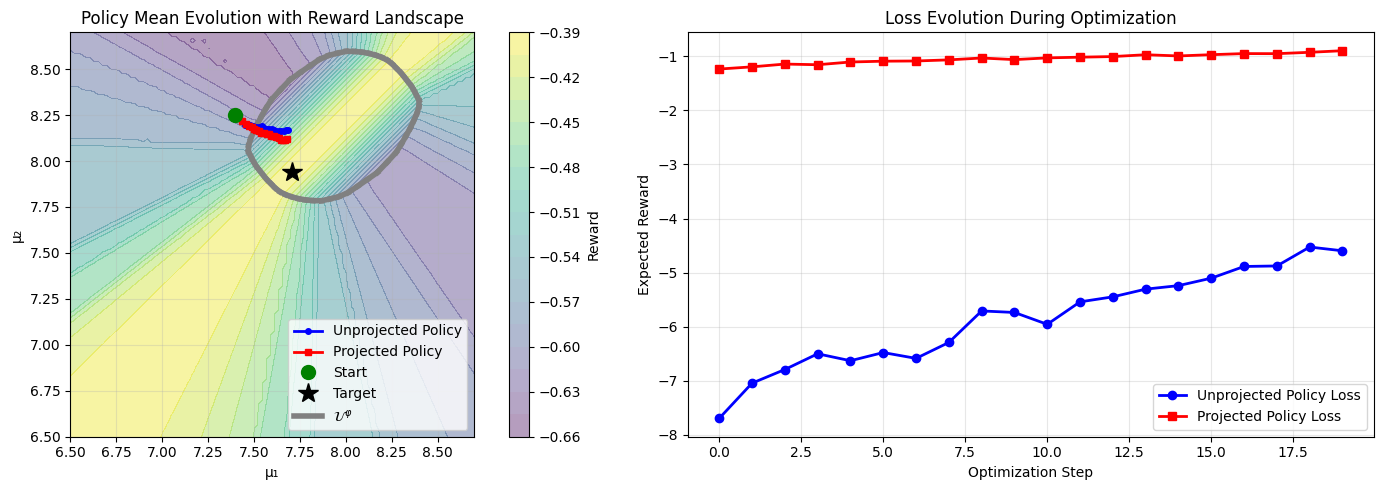

In [ ]:
# Plot the evolution of both policies
fig, axes = plt.subplots(figsize=(15, 5), ncols=2)

# Convert histories to numpy for plotting
mu_unproj_np = th.stack(mu_unproj_history).detach().cpu().numpy()
mu_proj_np = th.stack(mu_proj_history).detach().cpu().numpy()

# Plot 1: Trajectory in 2D space with reward landscape
ax = axes[0]

# Create a grid for the reward landscape
u1_grid = np.linspace(6.5, 8.7, 100)
u2_grid = np.linspace(6.5, 8.7, 100)
U1, U2 = np.meshgrid(u1_grid, u2_grid)

# Compute rewards on the grid
grid_actions = th.tensor(np.stack([U1.ravel(), U2.ravel()], axis=1), dtype=th.float32)
# Project grid actions to safe set for fair evaluation
projected_grid_actions = projection_layer(
    grid_actions,
    th.tensor(safe_action_set.c.flatten(), dtype=th.float32),
    th.tensor(safe_action_set.G, dtype=th.float32)
)[0]
# Compute next states for grid
next_states_grid = dynamics_quadrotor(state=CURRENT_STATE.reshape(1, -1), actions=projected_grid_actions, env=env)
# Compute rewards
rewards_grid = reward_quadrotor(state=next_states_grid, action=projected_grid_actions)
rewards_grid = rewards_grid.detach().cpu().numpy().reshape(U1.shape)

# Plot reward landscape as colormap
contour = ax.contourf(U1, U2, rewards_grid, levels=20, cmap='viridis', alpha=0.4)
cbar = plt.colorbar(contour, ax=ax, label='Reward')

# Plot trajectories on top
ax.plot(mu_unproj_np[:, 0], mu_unproj_np[:, 1], 'b-o', label='Unprojected Policy', linewidth=2, markersize=4, zorder=3)
ax.plot(mu_proj_np[:, 0], mu_proj_np[:, 1], 'r-s', label='Projected Policy', linewidth=2, markersize=4, zorder=3)

# Mark start and end points
ax.plot(mu_start[0], mu_start[1], 'go', markersize=10, label='Start', zorder=4)
ax.plot(opt_safe_action[0], opt_safe_action[1], 'k*', markersize=15, label='Target', zorder=4)

# Add safe action set boundary
plot_shape(ax, safe_action_set.vertices, label=r'$\mathcal{U}^\varphi$', color='grey')
ax.set_xlabel('μ₁')
ax.set_ylabel('μ₂')
ax.set_title('Policy Mean Evolution with Reward Landscape')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([6.5, 8.7])
ax.set_ylim([6.5, 8.7])
ax.set_aspect('equal')

# Plot 2: Loss evolution over time
ax = axes[1]
ax.plot(range(len(loss_unproj_history)), loss_unproj_history, 'b-o', label='Unprojected Policy Loss', linewidth=2)
ax.plot(range(len(loss_proj_history)), loss_proj_history, 'r-s', label='Projected Policy Loss', linewidth=2)
ax.set_xlabel('Optimization Step')
ax.set_ylabel('Expected Reward')
ax.set_title('Loss Evolution During Optimization')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()